In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from google.colab import drive
from tqdm import tqdm

# Audio segment creation
import math

from sklearn import metrics

# Graphics
import seaborn as sns

In [ ]:
# Connect Google Drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path to labels and processed data file, json format.
JSON_PATH = '/content/drive/MyDrive/prev-experiments/cnn_4/out/data.json'

# Path to saved model
MODEL_PATH = '/content/drive/MyDrive/prev-experiments/artifacts/model/cnn.h5'

# Genres to analyze
genres = ['deep_house', 'tech_house', 'melodic_techno', 'progressive', 'techno_peak_time', 'hard_techno', 'minimal', 'trance']

In [ ]:
def load_data(json_path):

    with open(json_path, 'r') as f:
        data = json.load(f)
    f.close()

    # Let's load our data into numpy arrays for TensorFlow compatibility.
    X = np.array(data["mfcc"])
    y = np.array(data["labels"])

    return X, y

In [ ]:
def prepare_datasets(inputs, targets, split_size):

    # Group inputs by segments of same track
    group_indexes = range(len(inputs) // 40)

    # Creating a validation set and a test set.
    group_indexes_train, group_indexes_val = train_test_split(group_indexes, test_size=split_size)
    group_indexes_train, group_indexes_test = train_test_split(group_indexes_train, test_size=split_size)

    print(group_indexes_train)
    print(group_indexes_val)
    print(group_indexes_test)

    # Create datasets
    inputs_train = []
    inputs_val = []
    inputs_test = []
    targets_train = []
    targets_val = []
    targets_test = []

    for i_tr in group_indexes_train:
      for j_tr in range(i_tr*40, i_tr*40+40):
        inputs_train.append(inputs[j_tr])
        targets_train.append(targets[j_tr])

    for i_te in group_indexes_test:
      for j_te in range(i_te*40, i_te*40+40):
        inputs_test.append(inputs[j_te])
        targets_test.append(targets[j_te])

    for i_val in group_indexes_val:
      for j_val in range(i_val*40, i_val*40+40):
        inputs_val.append(inputs[j_val])
        targets_val.append(targets[j_val])

    inputs_train = np.array(inputs_train)
    inputs_val = np.array(inputs_val)
    inputs_test = np.array(inputs_test)
    targets_train = np.array(targets_train)
    targets_val = np.array(targets_val)
    targets_test = np.array(targets_test)

    # Our CNN model expects 3D input shape.
    inputs_train = inputs_train[..., np.newaxis]
    inputs_val = inputs_val[..., np.newaxis]
    inputs_test = inputs_test[..., np.newaxis]

    return inputs_train, inputs_val, inputs_test, targets_train, targets_val, targets_test

In [ ]:
def design_model(input_shape):

    # Let's design the model architecture.
    model = tf.keras.models.Sequential([

        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2), padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2), padding='same'),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(32, (2,2), activation='relu'),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(len(np.unique(targets)), activation='softmax')
    ])

    return model

In [ ]:
def make_prediction(model, X, y):
    predictions = model.predict(X)

    total_accuracy = 0

    for i in range(len(predictions) // 40):
      song_pred = np.zeros(len(genres))
      for j in range(i*40, (i+1)*40):
        for k in range(len(genres)):
            song_pred[k] += predictions[j][k]

      predicted_genre = np.argmax(song_pred)
      if(i==0):
        print(song_pred)
      true_genre = y[i*40]
      if predicted_genre == true_genre:
        total_accuracy += 1

    total_songs = len(predictions) // 40
    total_accuracy /= total_songs
    print("Total accuracy: " + str(total_accuracy))

In [ ]:
def plot_performance(hist):

    acc = hist.history['acc']
    val_acc = hist.history['val_acc']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']

    epochs = range(len(acc))

    plt.plot(epochs, acc, 'r', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, 'r', label='Training Loss')
    plt.plot(epochs, val_loss, 'b', label='Validation Loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

In [ ]:
inputs, targets = load_data(json_path=JSON_PATH)

Xtrain, Xval, Xtest, ytrain, yval, ytest = prepare_datasets(inputs, targets, 0.2)

input_shape = (Xtrain.shape[1], Xtrain.shape[2], 1)

[646, 26, 288, 611, 585, 798, 482, 130, 742, 758, 360, 304, 412, 199, 343, 233, 91, 484, 635, 673, 57, 155, 221, 318, 579, 452, 218, 167, 63, 162, 550, 510, 582, 548, 464, 177, 15, 44, 377, 12, 345, 1, 388, 320, 184, 248, 59, 60, 777, 274, 557, 748, 207, 605, 405, 666, 657, 156, 642, 170, 649, 344, 630, 778, 647, 401, 303, 600, 453, 625, 596, 491, 529, 32, 69, 271, 364, 442, 227, 590, 151, 337, 568, 723, 361, 174, 112, 574, 573, 747, 249, 730, 98, 779, 126, 39, 239, 114, 338, 373, 727, 707, 524, 356, 645, 325, 294, 168, 710, 278, 201, 474, 413, 358, 371, 5, 496, 687, 236, 84, 786, 115, 183, 219, 395, 143, 784, 359, 409, 728, 314, 208, 448, 767, 440, 718, 299, 212, 450, 799, 607, 393, 323, 485, 339, 468, 297, 552, 732, 722, 554, 49, 181, 684, 410, 547, 569, 502, 679, 514, 455, 289, 350, 293, 58, 387, 528, 425, 752, 204, 73, 65, 399, 334, 215, 106, 472, 511, 348, 41, 117, 608, 584, 602, 690, 51, 561, 501, 160, 774, 526, 427, 329, 42, 100, 206, 137, 420, 78, 411, 308, 374, 407, 238, 213, 

In [ ]:
model = design_model(input_shape)

# Selection of the optimizer, loss type and metrics for performance evaluation.
model.compile(optimizer = tf.keras.optimizers.RMSprop(lr=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics = ['acc']
                  )

model.summary()

# Training the model.
history = model.fit(Xtrain, ytrain,
                    validation_data=(Xval, yval),
                    epochs=30,
                    batch_size=32,
                    )

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 11, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 6, 32)        0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 64, 6, 32)        128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 62, 4, 32)         9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 31, 2, 32)        0         
 2D)                                                             
                                                        

/usr/local/lib/python3.8/dist-packages/keras/optimizers/optimizer_v2/rmsprop.py:135: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(RMSprop, self).__init__(name, **kwargs)


Epoch 1/30
640/640 [==============================] - 47s 71ms/step - loss: 1.4442 - acc: 0.4624 - val_loss: 1.3206 - val_acc: 0.5316
Epoch 2/30
640/640 [==============================] - 48s 75ms/step - loss: 1.0144 - acc: 0.6219 - val_loss: 1.2334 - val_acc: 0.5864
Epoch 3/30
640/640 [==============================] - 48s 75ms/step - loss: 0.8510 - acc: 0.6843 - val_loss: 1.2087 - val_acc: 0.5975
Epoch 4/30
640/640 [==============================] - 48s 75ms/step - loss: 0.7588 - acc: 0.7211 - val_loss: 1.2779 - val_acc: 0.5689
Epoch 5/30
640/640 [==============================] - 52s 81ms/step - loss: 0.7011 - acc: 0.7419 - val_loss: 1.2442 - val_acc: 0.5930
Epoch 6/30
640/640 [==============================] - 52s 82ms/step - loss: 0.6509 - acc: 0.7584 - val_loss: 1.1509 - val_acc: 0.6259
Epoch 7/30
640/640 [==============================] - 64s 100ms/step - loss: 0.6121 - acc: 0.7753 - val_loss: 1.4106 - val_acc: 0.5866
Epoch 8/30
640/640 [==============================] - 64s 99m

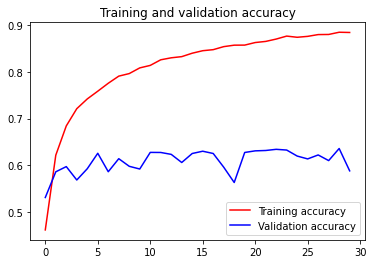

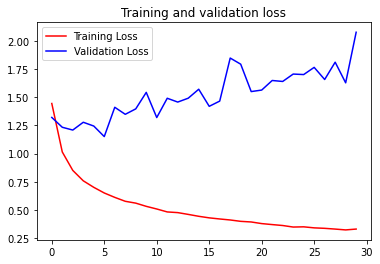

160/160 [==============================] - 13s 78ms/step
[ 0.36373479 34.33286926  2.07116135  2.22886837  0.13576816  0.47137965
  0.1398965   0.25632039]
Total accuracy: 0.71875


In [ ]:
plot_performance(history)

# Testing the model on never seen before data.
make_prediction(model, Xtest, ytest)

160/160 [==============================] - 8s 48ms/step
              precision    recall  f1-score   support

           0       0.71      0.62      0.67        16
           1       0.71      0.86      0.77        14
           2       0.81      0.77      0.79        22
           3       0.35      0.75      0.48         8
           4       0.57      0.80      0.67        15
           5       0.92      0.71      0.80        17
           6       0.92      0.71      0.80        17
           7       0.92      0.58      0.71        19

    accuracy                           0.72       128
   macro avg       0.74      0.72      0.71       128
weighted avg       0.78      0.72      0.73       128



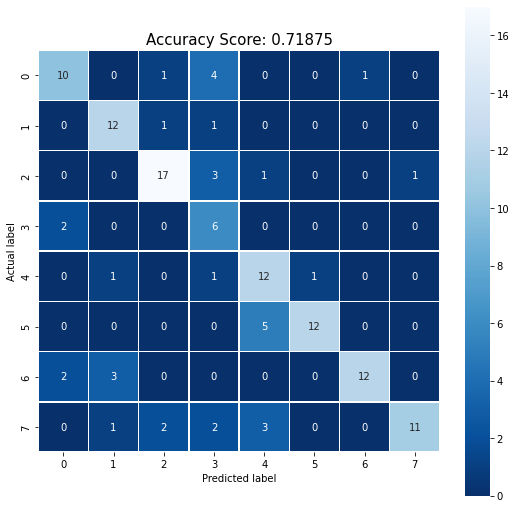

In [ ]:
predictions = model.predict(Xtest)

total_accuracy = 0

y_actual = []
y_predicted = []

for i in range(len(predictions) // 40):
  song_pred = np.zeros(len(genres))
  for j in range(i*40, (i+1)*40):
    for k in range(len(genres)):
        song_pred[k] += predictions[j][k]

  predicted_genre = np.argmax(song_pred)
  true_genre = ytest[i*40]
  if predicted_genre == true_genre:
        total_accuracy += 1
  y_actual.append(true_genre)
  y_predicted.append(predicted_genre)


total_songs = len(predictions) // 40
total_accuracy /= total_songs

confusion_matrix = metrics.confusion_matrix(y_actual, y_predicted)

plt.figure(figsize=(9,9))
sns.heatmap(confusion_matrix, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(total_accuracy)
plt.title(all_sample_title, size = 15);

print(metrics.classification_report(y_actual, y_predicted))

160/160 [==============================] - 10s 64ms/step
              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.92      0.86      0.89        14
           2       0.83      0.91      0.87        22
           3       0.78      0.88      0.82         8
           4       0.88      1.00      0.94        15
           5       1.00      0.88      0.94        17
           6       1.00      0.88      0.94        17
           7       0.93      0.74      0.82        19

    accuracy                           0.88       128
   macro avg       0.89      0.89      0.88       128
weighted avg       0.89      0.88      0.88       128



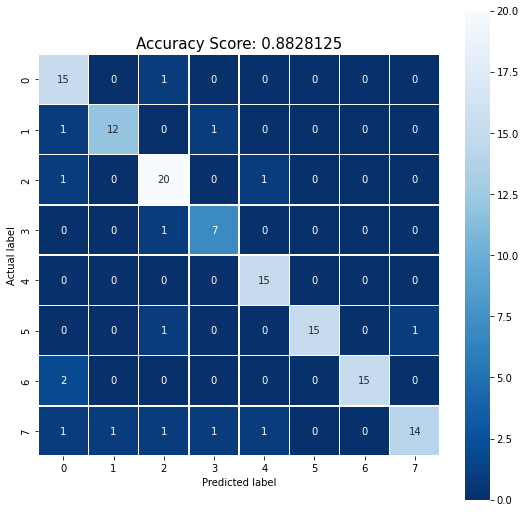

In [ ]:
predictions = model.predict(Xtest)

total_accuracy = 0

y_actual = []
y_predicted = []

for i in range(len(predictions) // 40):
  song_pred = np.zeros(len(genres))
  for j in range(i*40, (i+1)*40):
    for k in range(len(genres)):
        song_pred[k] += predictions[j][k]

  predicted_genres = np.argpartition(song_pred, -2)[-2:]
  true_genre = ytest[i*40]
  predicted_genre = predicted_genres[0]
  if true_genre in predicted_genres:
        total_accuracy += 1
        predicted_genre = true_genre
  y_actual.append(true_genre)
  y_predicted.append(predicted_genre)


total_songs = len(predictions) // 40
total_accuracy /= total_songs

confusion_matrix = metrics.confusion_matrix(y_actual, y_predicted)

plt.figure(figsize=(9,9))
sns.heatmap(confusion_matrix, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(total_accuracy)
plt.title(all_sample_title, size = 15);

print(metrics.classification_report(y_actual, y_predicted))

In [ ]:
# Save model

model.save(MODEL_PATH)